In [12]:
!pip install optuna
### Import libraries ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import kendalltau
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import json
import copy
import optuna
import shutil


In [13]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Update this path to the folder containing your data files (CSV and NPY)
folder_path = '/content/drive/MyDrive/my_data_folder/'

X_train_path = os.path.join(folder_path, 'X_train.csv')
X_test_path = os.path.join(folder_path, 'X_test.csv')
X_val_path = os.path.join(folder_path, 'X_val.csv')
y_train_path = os.path.join(folder_path, 'y_train.csv')
y_test_path = os.path.join(folder_path, 'y_test.csv')
y_val_path = os.path.join(folder_path, 'y_val.csv')

print(f"Data paths set. Checking if files exist...")
all_file_paths = [
    X_train_path, X_test_path, X_val_path,
    y_train_path, y_test_path, y_val_path
]
for f in all_file_paths:
    print(f"{f}: {'Found' if os.path.exists(f) else 'Not Found'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data paths set. Checking if files exist...
/content/drive/MyDrive/my_data_folder/X_train.csv: Found
/content/drive/MyDrive/my_data_folder/X_test.csv: Found
/content/drive/MyDrive/my_data_folder/X_val.csv: Found
/content/drive/MyDrive/my_data_folder/y_train.csv: Found
/content/drive/MyDrive/my_data_folder/y_test.csv: Found
/content/drive/MyDrive/my_data_folder/y_val.csv: Found


In [14]:
SEED = 101
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
g = torch.Generator()
g.manual_seed(101)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
TARGET_VARIABLE = "Mole fraction"

In [15]:
# X_train = pd.read_csv("X_train.csv")
# X_test = pd.read_csv("X_test.csv")
# X_val = pd.read_csv("X_val.csv")
# y_train = pd.read_csv("y_train.csv")
# y_test = pd.read_csv("y_test.csv")
# y_val = pd.read_csv("y_val.csv")

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
X_val = pd.read_csv(X_val_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)
y_val = pd.read_csv(y_val_path)

In [16]:
X_train.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)
X_test.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)
X_val.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

def to_loader(X, y, batch_size=512, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32).squeeze().unsqueeze(1)
    )
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        generator=g if shuffle else None,
        worker_init_fn=lambda worker_id: np.random.seed(101 + worker_id) if shuffle else None
    )

train_loader = to_loader(X_train_scaled, y_train, shuffle=True)
val_loader   = to_loader(X_val_scaled, y_val)

In [19]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
            nn.Hardtanh(min_val=0.0, max_val=1.0)
        )

    def forward(self, x):
        return self.net(x)

In [20]:
def objective(trial):
    lr         = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    dropout    = trial.suggest_float('dropout', 0.1, 0.4)
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])

    model = MLPRegressor(X_train.shape[1], dropout=dropout,
                         hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    fast_train_loader = to_loader(X_train_scaled, y_train, batch_size=2048, shuffle=True)
    fast_val_loader   = to_loader(X_val_scaled,   y_val,   batch_size=2048)
    best_trial_loss = float('inf')
    for epoch in range(50):
        model.train()
        for X_batch, y_batch in fast_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = np.mean([
                criterion(model(X_b.to(device)), y_b.to(device)).item()
                for X_b, y_b in fast_val_loader
            ])
            best_trial_loss = min(best_trial_loss, val_loss)
        scheduler.step(val_loss)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_trial_loss

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
)
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Best params:", study.best_params)
print("Best val MSE:", study.best_value)

[I 2026-04-08 00:16:18,977] A new study created in memory with name: no-name-ddfd6ac3-d1bd-4723-a3db-2832a03e9e9e


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-08 00:17:36,924] Trial 0 finished with value: 0.027860259947677452 and parameters: {'lr': 9.034222666832618e-05, 'dropout': 0.10532068911761729, 'hidden_dim': 512}. Best is trial 0 with value: 0.027860259947677452.
[I 2026-04-08 00:18:52,859] Trial 1 finished with value: 0.024661314984162647 and parameters: {'lr': 0.0017576632921263897, 'dropout': 0.2823035031256748, 'hidden_dim': 128}. Best is trial 1 with value: 0.024661314984162647.
[I 2026-04-08 00:20:10,342] Trial 2 finished with value: 0.07075917596618335 and parameters: {'lr': 1.4178344011011865e-05, 'dropout': 0.12436551363809654, 'hidden_dim': 512}. Best is trial 1 with value: 0.024661314984162647.
[I 2026-04-08 00:20:19,879] Trial 3 pruned. 
[I 2026-04-08 00:20:29,372] Trial 4 pruned. 
[I 2026-04-08 00:20:38,974] Trial 5 pruned. 
[I 2026-04-08 00:20:48,471] Trial 6 pruned. 
[I 2026-04-08 00:20:58,270] Trial 7 pruned. 
[I 2026-04-08 00:21:07,948] Trial 8 pruned. 
[I 2026-04-08 00:21:17,922] Trial 9 pruned. 
[I 2026-

In [21]:
# Training loop

best_params = study.best_params
model = MLPRegressor(X_train.shape[1],
                     hidden_dim=best_params['hidden_dim'],
                     dropout=best_params['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_loss = float('inf')
best_model_state = None
train_loss_history = []
val_loss_history = []

n_epochs = 300
for epoch in range(n_epochs):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_losses = [
            criterion(model(X_b.to(device)), y_b.to(device)).item()
            for X_b, y_b in val_loader
        ]
    val_loss = np.mean(val_losses)
    scheduler.step(np.mean(val_losses))
    # Save best weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
    # Add at bottom of the epoch loop:
    train_loss_history.append(np.mean(train_losses))
    val_loss_history.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} — Train MSE: {np.mean(train_losses):.4f} — Val MSE: {val_loss:.4f}")


Epoch 10/300 — Train MSE: 0.0374 — Val MSE: 0.0336
Epoch 20/300 — Train MSE: 0.0290 — Val MSE: 0.0264
Epoch 30/300 — Train MSE: 0.0270 — Val MSE: 0.0256
Epoch 40/300 — Train MSE: 0.0255 — Val MSE: 0.0247
Epoch 50/300 — Train MSE: 0.0245 — Val MSE: 0.0233
Epoch 60/300 — Train MSE: 0.0238 — Val MSE: 0.0259
Epoch 70/300 — Train MSE: 0.0230 — Val MSE: 0.0225
Epoch 80/300 — Train MSE: 0.0209 — Val MSE: 0.0196
Epoch 90/300 — Train MSE: 0.0197 — Val MSE: 0.0183
Epoch 100/300 — Train MSE: 0.0197 — Val MSE: 0.0185
Epoch 110/300 — Train MSE: 0.0186 — Val MSE: 0.0176
Epoch 120/300 — Train MSE: 0.0184 — Val MSE: 0.0174
Epoch 130/300 — Train MSE: 0.0182 — Val MSE: 0.0176
Epoch 140/300 — Train MSE: 0.0181 — Val MSE: 0.0175
Epoch 150/300 — Train MSE: 0.0179 — Val MSE: 0.0172
Epoch 160/300 — Train MSE: 0.0179 — Val MSE: 0.0173
Epoch 170/300 — Train MSE: 0.0178 — Val MSE: 0.0172
Epoch 180/300 — Train MSE: 0.0178 — Val MSE: 0.0172
Epoch 190/300 — Train MSE: 0.0178 — Val MSE: 0.0172
Epoch 200/300 — Train

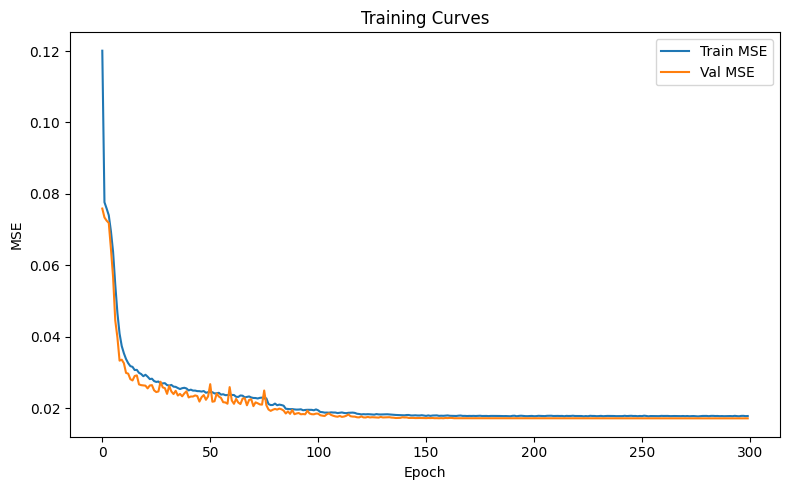

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Train MSE')
plt.plot(val_loss_history, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves_mlp.png', dpi=150)
plt.show()

In [23]:
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss': best_val_loss,
    'input_dim': X_train.shape[1],
}, 'mlp_baseline.pth')

In [24]:
def evaluate_model(y_test, y_pred, show_plot=False, save_file=False, save_path="./results.json"):
    """Evaluate model performance given true and predicted values."""
    y_test = np.array(y_test).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    tau = kendalltau(y_test, y_pred).correlation

    # Bootstrap CI
    rng = np.random.default_rng(101)
    mae_scores, mse_scores, r2_scores, tau_scores = [], [], [], []

    for _ in range(1000):
        idx = rng.integers(0, len(y_test), len(y_test))
        mae_scores.append(mean_absolute_error(y_test[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_test[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_test[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_test[idx], y_pred[idx]).correlation)

    mae_std = np.std(mae_scores)
    mse_std = np.std(mse_scores)
    r2_std  = np.std(r2_scores)
    tau_std = np.std(tau_scores)

    mae_ci  = np.percentile(mae_scores, [2.5, 97.5])
    mse_ci  = np.percentile(mse_scores, [2.5, 97.5])
    r2_ci   = np.percentile(r2_scores,  [2.5, 97.5])
    tau_ci  = np.percentile(tau_scores, [2.5, 97.5])

    print(f"MAE          = {mae:.4f}, Std: {mae_std:.4f} (95% CI: {mae_ci[0]:.4f}–{mae_ci[1]:.4f})")
    print(f"MSE          = {mse:.4f}, Std: {mse_std:.4f} (95% CI: {mse_ci[0]:.4f}–{mse_ci[1]:.4f})")
    print(f"R²           = {r2:.4f}, Std: {r2_std:.4f} (95% CI: {r2_ci[0]:.4f}–{r2_ci[1]:.4f})")
    print(f"Kendall's τ  = {tau:.4f}, Std: {tau_std:.4f} (95% CI: {tau_ci[0]:.4f}–{tau_ci[1]:.4f})")

    if save_file:
        results = {"MAE": mae, "MSE": mse, "R2": r2, "Kendall_tau": tau}
        with open(save_path, "w") as f:
            json.dump(results, f)
        print(f"Results saved to {save_path}")

    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.1, s=10)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect fit")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Actual vs Predicted")
        plt.legend()
        plt.show()

In [25]:
# checkpoint = torch.load('mlp_baseline.pth', weights_only = False)
# model = MLPRegressor(checkpoint['input_dim']).to(device)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()

MAE          = 0.0635, Std: 0.0011 (95% CI: 0.0615–0.0656)
MSE          = 0.0165, Std: 0.0004 (95% CI: 0.0157–0.0173)
R²           = 0.8266, Std: 0.0046 (95% CI: 0.8178–0.8353)
Kendall's τ  = 0.7812, Std: 0.0038 (95% CI: 0.7738–0.7883)


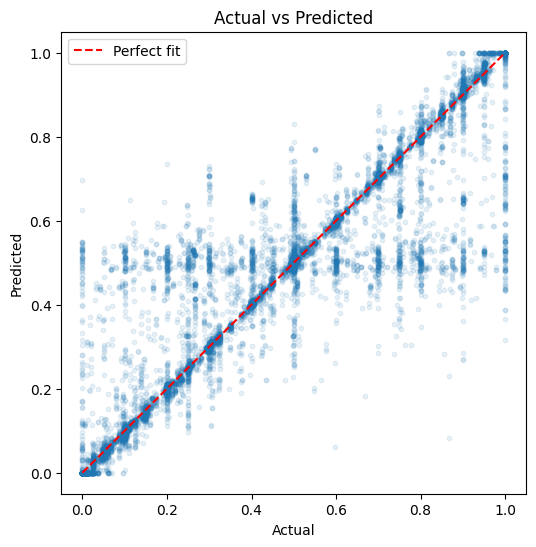

MAE          = 0.0649, Std: 0.0011 (95% CI: 0.0626–0.0670)
MSE          = 0.0171, Std: 0.0005 (95% CI: 0.0162–0.0180)
R²           = 0.8195, Std: 0.0048 (95% CI: 0.8107–0.8289)
Kendall's τ  = 0.7769, Std: 0.0040 (95% CI: 0.7691–0.7848)


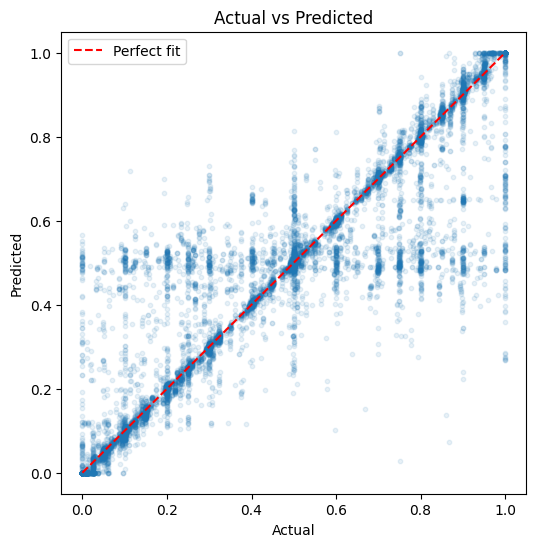

In [26]:
# Restore best weights
model.load_state_dict(best_model_state)

# Predict
model.eval()
with torch.no_grad():
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_pred_val = model(X_val_tensor).cpu().numpy().flatten()
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    y_pred_test = model(X_test_tensor).cpu().numpy().flatten()

# Evaluate
evaluate_model(y_test, y_pred_test, show_plot=True)
evaluate_model(y_val, y_pred_val, show_plot=True)

In [27]:
history_df = pd.DataFrame({
    'Epoch': range(1, len(train_loss_history) + 1),
    'Train MSE': train_loss_history,
    'Val MSE': val_loss_history
})

history_df.to_csv('training_loss_history_baseline.csv', index=False)
print("Training loss history saved to training_loss_history_baseline.csv")

# Also copy this file to Google Drive
shutil.copy('training_loss_history_baseline.csv', os.path.join(folder_path, 'training_loss_history_baseline.csv'))
print(f"Saved training_loss_histor_baseline.csv to {folder_path}")

Training loss history saved to training_loss_history_baseline.csv
Saved training_loss_histor_baseline.csv to /content/drive/MyDrive/my_data_folder/


In [28]:

# List of files to save
files_to_save = ["mlp_baseline.pth", "training_curves_mlp.png"]

# Copy each file to your specified Google Drive folder
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(folder_path, f))
        print(f"Saved {f} to {folder_path}")
    else:
        print(f"File {f} not found in local storage.")

Saved mlp_baseline.pth to /content/drive/MyDrive/my_data_folder/
Saved training_curves_mlp.png to /content/drive/MyDrive/my_data_folder/
